**Data required:** Place `participant_data.csv` in `01_empirical/data/`. See `01_empirical/data/README.md` for the data source (Sparkman et al. 2022, *Nature Communications*).

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

SMALL  = 11
MEDIUM = 14
matplotlib.rc('font',   size=SMALL)
matplotlib.rc('axes',   titlesize=MEDIUM)
matplotlib.rc('axes',   labelsize=MEDIUM)
matplotlib.rc('xtick',  labelsize=SMALL)
matplotlib.rc('ytick',  labelsize=SMALL)
matplotlib.rc('legend', fontsize=SMALL)

COL_GREY    = '#626262'
COL_BLACK   = '#222222'
COL_RED     = '#f0a0a0'   # light coral for Republicans
COL_DEM     = '#7aaae0'   # light blue for Democrats
COL_DEMFOX  = '#c0aacb'   # light muted purple for Dems who watch Fox
COL_ALL     = '#c8c8c8'   # light grey for all-respondents panel

ACTUAL_SUPPORT = 66
CARBON_TAX_COL = 'GRID_GTS1_2_GTS1'
PARTY_COL      = 'QPID1'
FOX_COL        = 'GRID_GTS3_6_GTS3'

In [112]:
from pyprojroot import here

df = pd.read_csv(here() / '01_empirical' / 'data' / 'participant_data.csv')

df['watches_fox'] = df[FOX_COL] >= 3

df_all  = df.copy()
df_dem  = df[df[PARTY_COL] == 1].copy()
df_rep  = df[df[PARTY_COL] == 2].copy()
df_dem_fox = df[(df[PARTY_COL] == 1) & df['watches_fox']].copy()

print(f'All: {len(df_all)}, Dem: {len(df_dem)}, Rep: {len(df_rep)}, Dem+Fox: {len(df_dem_fox)}')

All: 6119, Dem: 2154, Rep: 1816, Dem+Fox: 488


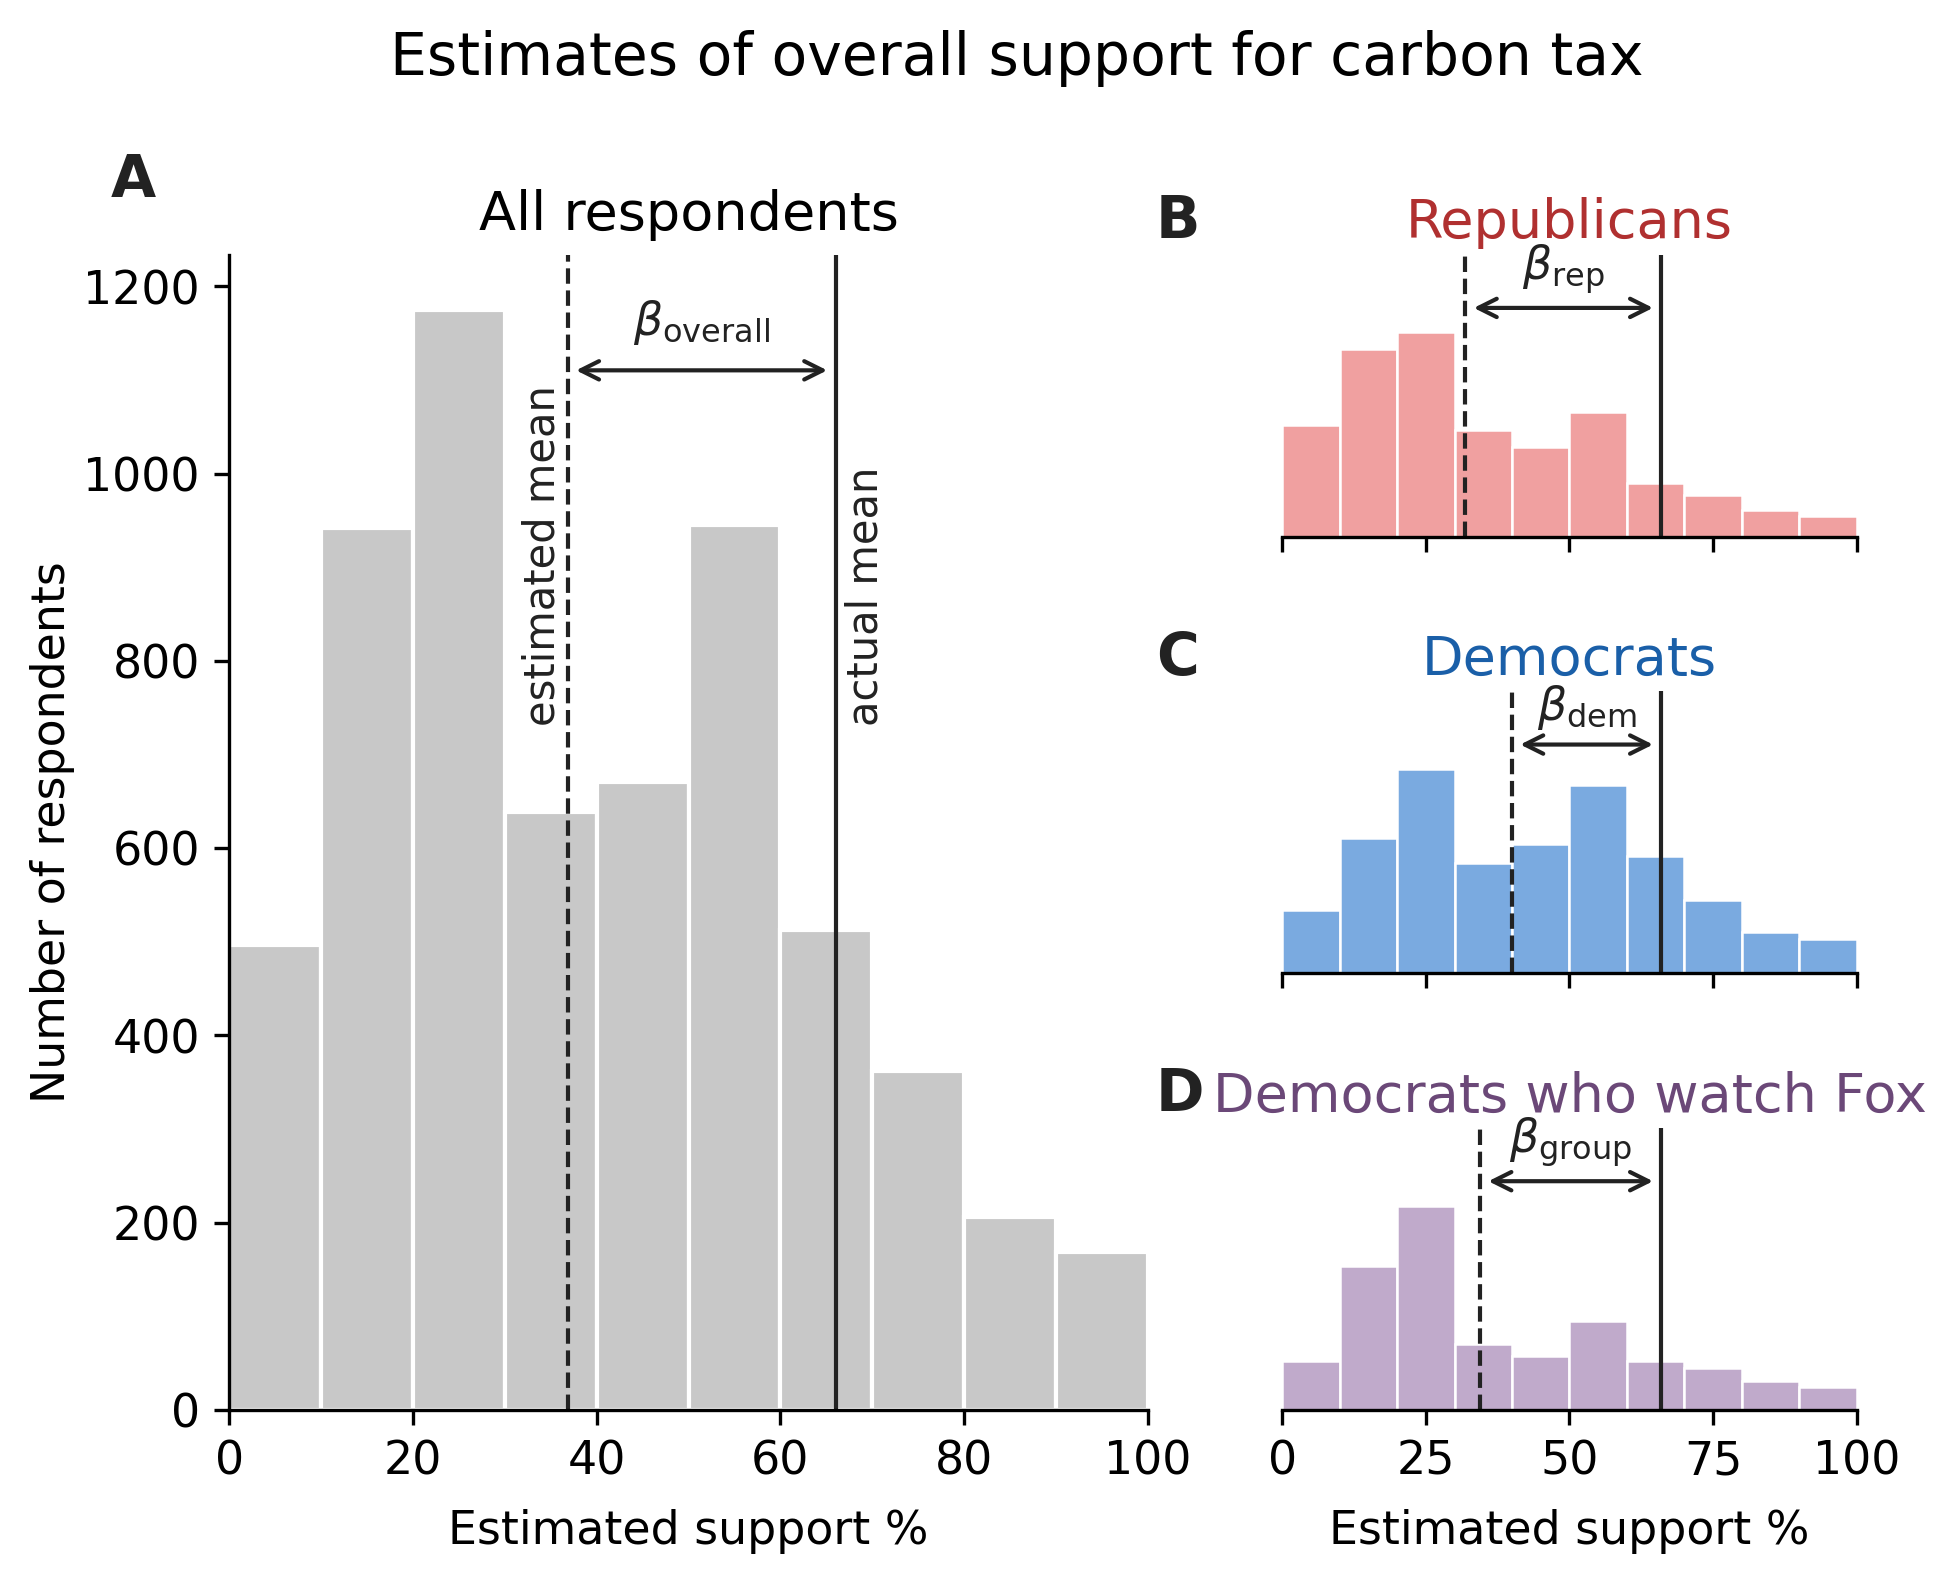

In [113]:
import seaborn as sns

SMALL_SIZE  = 11
MEDIUM_SIZE = 13
DPI         = 300

# darker versions of bar colors for readable titles
TITLE_RED    = '#b03030'
TITLE_DEM    = '#1a5fa8'
TITLE_DEMFOX = '#6b4878'


def add_panel_label(ax, letter, inside=False):
    if inside:
        ax.text(-0.22, 1.22, letter, transform=ax.transAxes,
                fontsize=MEDIUM_SIZE + 1, fontweight='bold',
                va='top', ha='left', color=COL_BLACK)
    else:
        ax.text(-0.08, 1.04, letter, transform=ax.transAxes,
                fontsize=MEDIUM_SIZE + 1, fontweight='bold',
                va='bottom', ha='right', color=COL_BLACK)


def hist_panel(ax, vals, color, title, ylabel=True, beta_label=None, panel_letter=None):
    ax.hist(vals, bins=10, range=(0, 100), histtype='bar', color=color, edgecolor='white')
    sns.despine(ax=ax)
    ymax = ax.get_ylim()[1]
    mean_val = vals.mean()

    ax.axvline(mean_val,       color=COL_BLACK, linestyle='--', linewidth=1)
    ax.text(mean_val - 5, ymax * 0.6, 'estimated mean', rotation=90,
            color=COL_BLACK, fontsize=SMALL_SIZE - 1)
    ax.axvline(ACTUAL_SUPPORT, color=COL_BLACK, linestyle='-',  linewidth=1)
    ax.text(ACTUAL_SUPPORT + 1, ymax * 0.6, 'actual mean', rotation=90,
            color=COL_BLACK, fontsize=SMALL_SIZE - 1)

    if beta_label is not None:
        arrow_y = ymax * 0.90
        ax.annotate('', xy=(ACTUAL_SUPPORT, arrow_y), xytext=(mean_val, arrow_y),
                    arrowprops=dict(arrowstyle='<->', color=COL_BLACK, lw=1))
        mid = (mean_val + ACTUAL_SUPPORT) / 2
        ax.text(mid, arrow_y + ymax * 0.02, beta_label,
                ha='center', va='bottom', fontsize=SMALL_SIZE, color=COL_BLACK)

    ax.set_xlim(0, 100)
    ax.set_xlabel('Estimated support %', labelpad=6, size=SMALL_SIZE)
    if ylabel:
        ax.set_ylabel('Number of respondents', labelpad=2, size=SMALL_SIZE)
    ax.set_title(title, size=MEDIUM_SIZE)
    if panel_letter:
        add_panel_label(ax, panel_letter, inside=False)


def right_panel(ax, vals, color, title_color, title, beta_label,
                panel_letter=None, show_xlabel=False):
    counts, edges = np.histogram(vals, bins=10, range=(0, 100))
    bin_mids  = (edges[:-1] + edges[1:]) / 2
    bin_width = edges[1] - edges[0]
    ax.bar(bin_mids, counts, width=bin_width, color=color, edgecolor='white',
           linewidth=0.6, align='center')

    raw_ymax = counts.max()
    ax.set_ylim(0, raw_ymax * 1.38)
    sns.despine(ax=ax, left=True)
    ax.set_yticks([])

    mean_val = vals.mean()
    ax.axvline(mean_val,       color=COL_BLACK, linestyle='--', linewidth=1)
    ax.axvline(ACTUAL_SUPPORT, color=COL_BLACK, linestyle='-',  linewidth=1)

    arrow_y = raw_ymax * 1.12
    ax.annotate('', xy=(ACTUAL_SUPPORT, arrow_y), xytext=(mean_val, arrow_y),
                arrowprops=dict(arrowstyle='<->', color=COL_BLACK, lw=1))
    mid = (mean_val + ACTUAL_SUPPORT) / 2
    ax.text(mid, arrow_y + raw_ymax * 0.06, beta_label,
            ha='center', va='bottom', fontsize=SMALL_SIZE, color=COL_BLACK)

    ax.set_xlim(0, 100)
    ax.set_title(title, color=title_color, size=MEDIUM_SIZE, pad=4)
    if panel_letter:
        add_panel_label(ax, panel_letter, inside=True)

    if show_xlabel:
        ax.set_xlabel('Estimated support %', labelpad=6, size=SMALL_SIZE)
    else:
        ax.tick_params(labelbottom=False)


# --- Figure 1 ---
fig1 = plt.figure(figsize=(7, 5), dpi=DPI)
gs_outer = fig1.add_gridspec(1, 2, width_ratios=[1.6, 1], wspace=0.18)

ax_main = fig1.add_subplot(gs_outer[0])
gs_right = gs_outer[1].subgridspec(3, 1, hspace=0.55)

hist_panel(ax_main, df_all[CARBON_TAX_COL].dropna(), COL_ALL, 'All respondents',
           ylabel=True, beta_label=r'$\beta_{\mathrm{overall}}$', panel_letter='A')

right_panel(fig1.add_subplot(gs_right[0]),
            df_rep[CARBON_TAX_COL].dropna(),
            COL_RED, TITLE_RED, 'Republicans',
            r'$\beta_{\mathrm{rep}}$',
            panel_letter='B', show_xlabel=False)

right_panel(fig1.add_subplot(gs_right[1]),
            df_dem[CARBON_TAX_COL].dropna(),
            COL_DEM, TITLE_DEM, 'Democrats',
            r'$\beta_{\mathrm{dem}}$',
            panel_letter='C', show_xlabel=False)

right_panel(fig1.add_subplot(gs_right[2]),
            df_dem_fox[CARBON_TAX_COL].dropna(),
            COL_DEMFOX, TITLE_DEMFOX, 'Democrats who watch Fox',
            r'$\beta_{\text{group}}$',
            panel_letter='D', show_xlabel=True)

fig1.suptitle('Estimates of overall support for carbon tax',
              fontsize=MEDIUM_SIZE + 1, y=1.03)

fig1.savefig(str(here() / "figures" / "carbon_tax_fig1_combined.pdf"), bbox_inches='tight')
plt.show()


**Figure 1.**
Distribution of estimates of public support for a carbon tax from Sparkman et al.'s survey [Sparkman et al., 2022].
Respondents were asked to estimate the percentage of Americans who support a carbon tax; actual mean support is 66% and the estimated mean is 37%.
**(A)** Distribution of estimates across all survey respondents (10-percentage-point bins). The solid vertical line marks actual public support (66%); the dashed line marks the mean estimated support (37%). The double-headed arrow denotes overall misperception $\beta_{\text{overall}}$, the gap between actual and mean estimated support.
**(B–D)** Distributions broken down by partisan group and media diet: Republicans (B), Democrats (C), and Democrats who report watching Fox News at least once per week (D). The double-headed arrow in each panel indicates group-level misperception $\beta_g$. Across all groups, respondents substantially underestimated public support for a carbon tax, with Republicans showing the largest misperception and Democrats who watch Fox News showing greater misperception than Democrats overall.